## Step 1: Load Dataset – Problem A (Class Attendance Prediction)

We begin by loading the dataset provided by GoodLife Fitness for class attendance prediction.
This dataset contains individual booking records with various member and class features.

Our goal is to predict whether a booked member will attend or not.


In [1]:
import pandas as pd

# Load the CSV file (replace with your local path if needed)
df_a = pd.read_csv("data/problem2.csv")

# Display first few rows and column info
df_a.columns = df_a.columns.str.strip()  # Remove extra whitespace
df_a.head()


,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


## Step 2: Data Cleaning & Preprocessing

### Tasks:
- Handle missing values (`weight`)
- Convert `days_before` to numeric
- Label encode categorical features:
    - `day_of_week`
    - `time`
    - `category`
- Drop irrelevant columns (like `booking_id`)


In [2]:
from sklearn.preprocessing import LabelEncoder

# Fill missing weights with median
df_a['weight'].fillna(df_a['weight'].median(), inplace=True)

# Convert 'days_before' to numeric
df_a['days_before'] = pd.to_numeric(df_a['days_before'], errors='coerce')

# Drop rows with invalid 'days_before'
df_a = df_a.dropna(subset=['days_before'])

# Label encode categorical features
label_encoders = {}
for col in ['day_of_week', 'time', 'category']:
    le = LabelEncoder()
    df_a[col] = le.fit_transform(df_a[col])
    label_encoders[col] = le

# Show processed dataset
df_a.head()


C:\Users\jaivb\AppData\Local\Temp\ipykernel_9236\798126746.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['weight'].fillna(df_a['weight'].median(), inplace=True)


,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8.0,8,1,4,0
1,2,10,79.01,2.0,2,0,3,0
2,3,16,74.53,14.0,5,0,4,0
3,4,5,86.12,10.0,0,0,2,0
4,5,15,69.29,8.0,6,0,3,0


## Step 3: Final Dataset Summary

Here are the features and their types after preprocessing.
We are now ready to move to train-test split and modeling.


In [3]:
df_a.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1475 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        1475 non-null   int64  
 1   months_as_member  1475 non-null   int64  
 2   weight            1475 non-null   float64
 3   days_before       1475 non-null   float64
 4   day_of_week       1475 non-null   int64  
 5   time              1475 non-null   int64  
 6   category          1475 non-null   int64  
 7   attended          1475 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 103.7 KB


## Step 4: Train-Test Split

We split the data into training and testing sets using an 80-20 ratio.
This helps evaluate how well our model generalizes to unseen data.


In [4]:
from sklearn.model_selection import train_test_split

# Define features and target
X_a = df_a.drop(columns=['booking_id', 'attended'])
y_a = df_a['attended']

# Perform train-test split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a)

print("Training set size:", X_train_a.shape)
print("Test set size:", X_test_a.shape)


Training set size: (1180, 6)
Test set size: (295, 6)


## Step 5: Model Training – Random Forest Classifier

We’ll use a **Random Forest Classifier**:
- Handles both numerical and categorical variables
- Robust to overfitting
- Provides built-in feature importance


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_a, y_train_a)

# Predict on test set
y_pred_a = rf_clf.predict(X_test_a)


## Step 6: Model Evaluation

We’ll evaluate the model using:
- Accuracy
- Precision, Recall, F1-score
- Confusion Matrix


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification metrics
print("Classification Report:")
print(classification_report(y_test_a, y_pred_a))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_a, y_pred_a))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       206
           1       0.61      0.49      0.55        89

    accuracy                           0.75       295
   macro avg       0.70      0.68      0.69       295
weighted avg       0.74      0.75      0.74       295

Confusion Matrix:
[[178  28]
 [ 45  44]]


## Step 7: Feature Importance

Let’s visualize which features influenced the model’s predictions the most.
This also supports transparency and explainability.


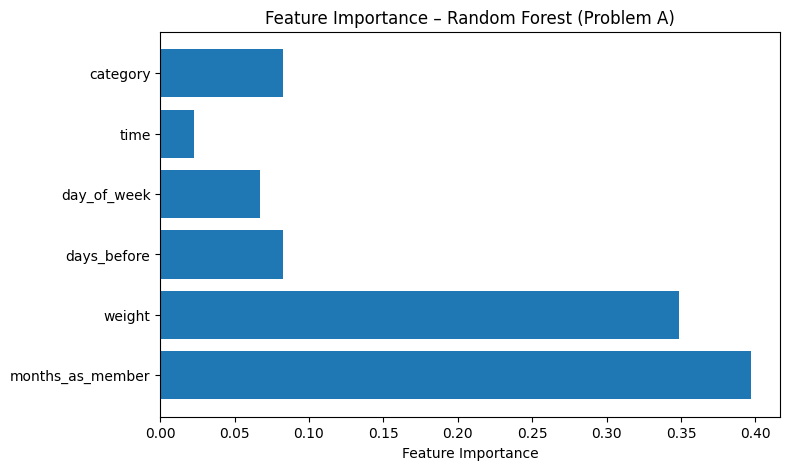

In [7]:
import matplotlib.pyplot as plt

# Extract feature importances
importances = rf_clf.feature_importances_
feature_names = X_a.columns

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance – Random Forest (Problem A)")
plt.show()
